Shape: (303, 18)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

   ca  target  thal_1  thal_2  thal_fixed  thal_normal  thal_reversible  
0   0       0   False   False        True        False            False  
1   3       1   False   False       False         True            False  
2   2       0   False   False       False        False             True  
3   0       0   False   False       False         True            False  
4   0       0   False   False       False         True            False  

Class distribution (Target):
target
0    220
1     

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.3687 - loss: 0.7423 - val_accuracy: 0.6000 - val_loss: 0.6636
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6959 - loss: 0.6293 - val_accuracy: 0.7200 - val_loss: 0.5820
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7696 - loss: 0.5449 - val_accuracy: 0.7200 - val_loss: 0.5149
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7926 - loss: 0.4800 - val_accuracy: 0.7600 - val_loss: 0.4593
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8157 - loss: 0.4297 - val_accuracy: 0.7600 - val_loss: 0.4106
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8387 - loss: 0.3912 - val_accuracy: 0.8000 - val_loss: 0.3697
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8479 - loss: 0.3619 - val_accuracy: 0.8000 - val_loss: 0.3371
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8571 - loss: 0.3397 - val_accuracy: 0.8400 - val_loss

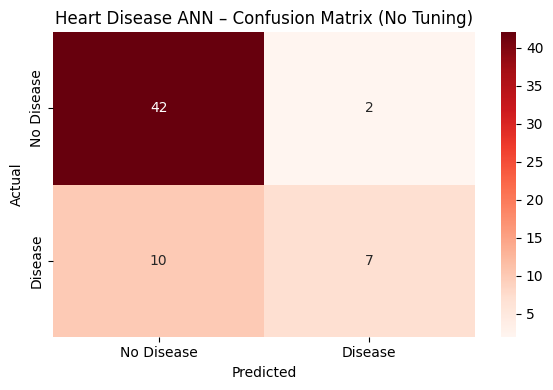

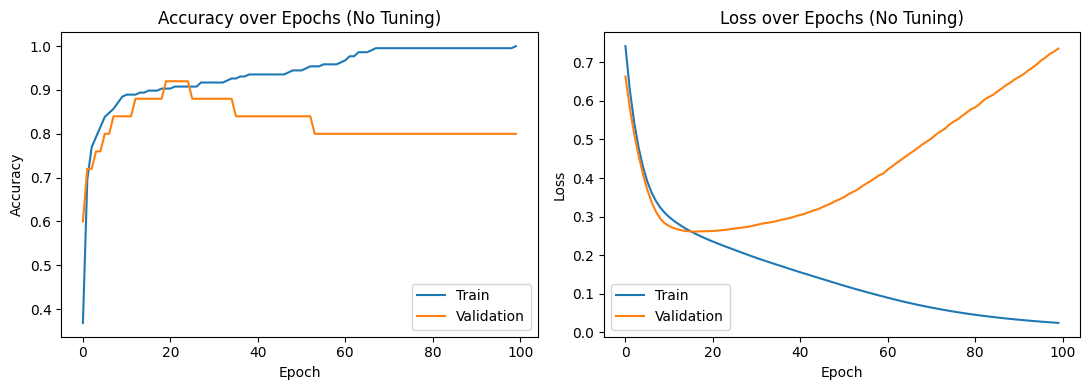


Architecture: Input(17) → Dense(64,relu) → Dense(32,relu) → Dense(1,sigmoid)
Optimizer: Adam(lr=0.001) | Epochs: 100 | Batch Size: 32


In [ ]:
# Artificial Neural Network – Without Hyperparameter Tuning
# Dataset: Heart Disease (heart.csv)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load dataset directly from URL
url = "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
df = pd.read_csv(url)

# Preprocessing: Convert categorical strings to numbers (Required for this dataset)
df = pd.get_dummies(df, columns=['thal'])

print("Shape:", df.shape)
print(df.head())
print("\nClass distribution (Target):")
print(df["target"].value_counts())

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Baseline ANN: Input(Features) → Dense(64,relu) → Dense(32,relu) → Dense(1,sigmoid)
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("\n========== ANN (No Tuning) ==========")
print(f"Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["No Disease", "Disease"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Confusion matrix plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Heart Disease ANN – Confusion Matrix (No Tuning)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over Epochs (No Tuning)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss over Epochs (No Tuning)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()

print(f"\nArchitecture: Input({X_train_scaled.shape[1]}) → Dense(64,relu) → Dense(32,relu) → Dense(1,sigmoid)")
print("Optimizer: Adam(lr=0.001) | Epochs: 100 | Batch Size: 32")

Starting hyperparameter search (20 trials)...
Search complete.

========== Best Hyperparameters Found ==========
num_layers    : 3
units_0      : 64
dropout_0    : 0.4
units_1      : 128
dropout_1    : 0.0
units_2      : 64
dropout_2    : 0.1
learning_rate : 0.0001
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.5853 - loss: 0.6793 - val_accuracy: 0.6800 - val_loss: 0.6675
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6498 - loss: 0.6601 - val_accuracy: 0.7200 - val_loss: 0.6543
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6774 - loss: 0.6392 - val_accuracy: 0.7200 - val_loss: 0.6417
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7189 - loss: 0.6255 - val_accuracy: 0.7200 - val_loss: 0.6293
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7189 - loss: 0.6190 - val_accuracy: 0.7200 - val_loss: 0.6167
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7235 - loss: 0.5970 - val_accuracy: 0.72

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

========== ANN (With Tuning) ==========
Accuracy: 90.16%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.98      0.93        44
     Disease       0.92      0.71      0.80        17

    accuracy                           0.90        61
   macro avg       0.91      0.84      0.87        61
weighted avg       0.90      0.90      0.90        61

Confusion Matrix:
 [[43  1]
 [ 5 12]]


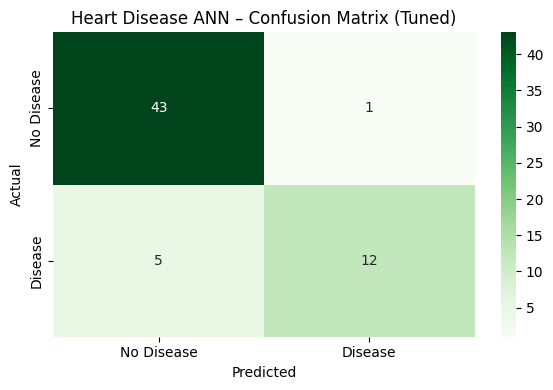

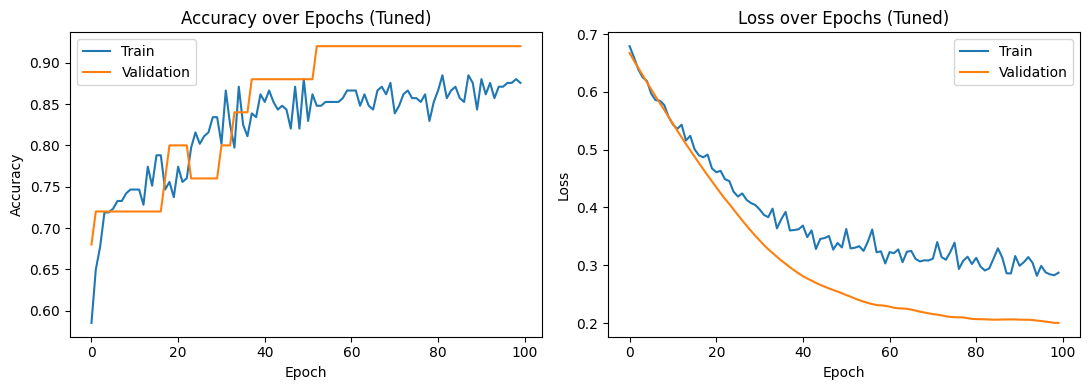

In [ ]:
# Artificial Neural Network – With Hyperparameter Tuning (Keras Tuner)
# Dataset: Heart Disease (heart.csv)

!pip install keras-tuner -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load dataset
url = "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
df = pd.read_csv(url)

# Preprocessing: Convert categorical strings to numbers (Required for Heart Dataset)
df = pd.get_dummies(df, columns=['thal'])

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]

# Model builder for Keras Tuner
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))

    # Tuning number of layers (1 to 3)
    for i in range(hp.Int('num_layers', 1, 3)):
        # Tuning number of units per layer
        units = hp.Choice(f'units_{i}', [16, 32, 64, 128])
        model.add(layers.Dense(units, activation='relu'))
        # Tuning dropout rate
        drop = hp.Float(f'dropout_{i}', 0.0, 0.4, step=0.1)
        if drop > 0.0:
            model.add(layers.Dropout(drop))

    model.add(layers.Dense(1, activation='sigmoid'))

    # Tuning learning rate
    lr = hp.Choice('learning_rate', [1e-4, 5e-4, 1e-3, 5e-3])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Keras Tuner — Random Search (20 trials)
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    seed=42,
    directory='kt_heart',
    project_name='ann_tuning',
    overwrite=True
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

print("Starting hyperparameter search (20 trials)...")
tuner.search(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
print("Search complete.")

# Best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n========== Best Hyperparameters Found ==========")
n_layers = best_hps.get('num_layers')
print(f"num_layers    : {n_layers}")
for i in range(n_layers):
    print(f"units_{i}      : {best_hps.get(f'units_{i}')}")
    print(f"dropout_{i}    : {best_hps.get(f'dropout_{i}')}")
print(f"learning_rate : {best_hps.get('learning_rate')}")

# Train best model fully
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history.history['accuracy'])}")

# Evaluate
y_pred_prob = best_model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)

print("\n========== ANN (With Tuning) ==========")
print(f"Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["No Disease", "Disease"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Confusion matrix plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Heart Disease ANN – Confusion Matrix (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over Epochs (Tuned)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss over Epochs (Tuned)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()